Lab 1 - Task 1 

In [1]:
import pandas as pd
import numpy as np

aqi = pd.read_csv("city_day.csv")
crop = pd.read_csv("crop_production.csv")

print("="*50)
print("AQI DATASET PROFILE")
print("="*50)

print("Shape :", aqi.shape)
print("\nColumns")
print(aqi.columns)

print("\nData Types")
print(aqi.dtypes)

print("\nMissing Values")
print(aqi.isnull().sum())

print("\nDuplicate Rows")
print(aqi.duplicated().sum())

print("\nStatistical Summary")
print(aqi.describe())


print("\n\n"+"="*50)
print("CROP DATASET PROFILE")
print("="*50)

print("Shape :", crop.shape)

print("\nColumns")
print(crop.columns)

print("\nData Types")
print(crop.dtypes)

print("\nMissing Values")
print(crop.isnull().sum())

print("\nDuplicate Rows")
print(crop.duplicated().sum())

print("\nStatistical Summary")
print(crop.describe())

AQI DATASET PROFILE
Shape : (29531, 16)

Columns
Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

Data Types
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

Missing Values
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Duplicate Rows
0

Statistical Summary
              PM

Lab 1 - Task 2

In [2]:
print("Before Cleaning")
print(aqi.isnull().sum())

# Numeric Columns

num_cols = aqi.select_dtypes(include=np.number).columns

for col in num_cols:
    aqi[col] = aqi[col].fillna(aqi[col].median())

# AQI Bucket

aqi["AQI_Bucket"] = aqi["AQI_Bucket"].fillna(
    aqi["AQI_Bucket"].mode()[0]
)

print("\nAfter Cleaning")
print(aqi.isnull().sum())


# Crop Dataset

print("\nCrop Before")
print(crop.isnull().sum())

crop["Production"] = crop["Production"].fillna(
    crop["Production"].median()
)

print("\nCrop After")
print(crop.isnull().sum())

Before Cleaning
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

After Cleaning
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

Crop Before
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

Crop After
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


Lab 1 - Task 3

In [3]:
aqi_before = len(aqi)
crop_before = len(crop)

aqi = aqi.drop_duplicates()
crop = crop.drop_duplicates()

aqi_after = len(aqi)
crop_after = len(crop)

print("AQI Records Removed :", aqi_before-aqi_after)
print("Crop Records Removed :", crop_before-crop_after)


# Standardize text columns

aqi["City"] = aqi["City"].str.strip().str.title()

crop["State_Name"] = (
    crop["State_Name"]
    .str.strip()
    .str.title()
)

crop["District_Name"] = (
    crop["District_Name"]
    .str.strip()
    .str.title()
)

print("Standardization Complete")

AQI Records Removed : 0
Crop Records Removed : 0
Standardization Complete


Lab 1 - Task 4

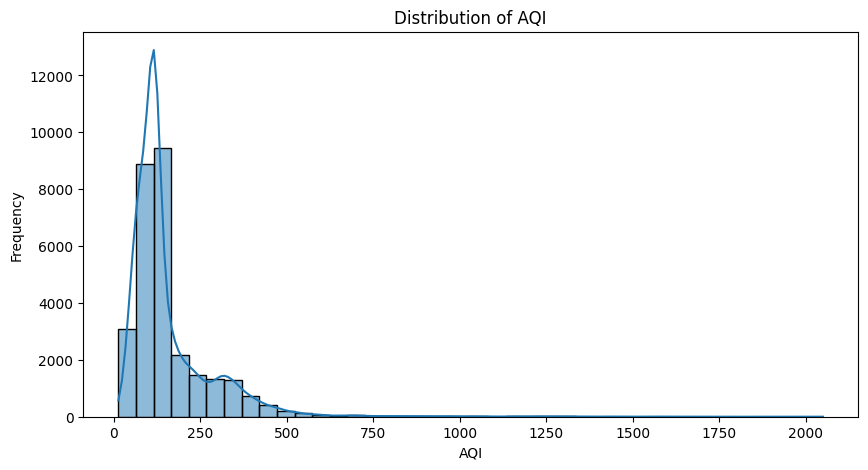

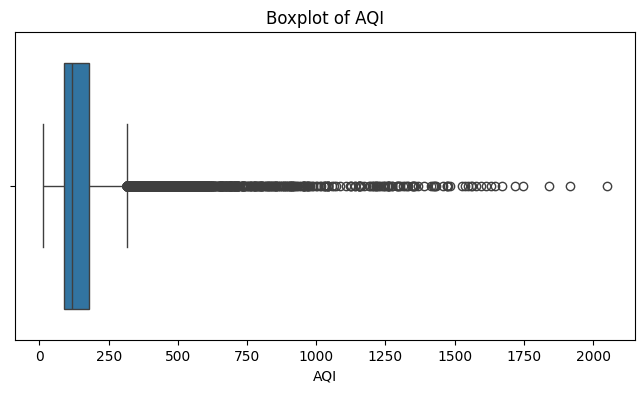

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(aqi["AQI"], bins=40, kde=True)

plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(8,4))
sns.boxplot(x=aqi["AQI"])

plt.title("Boxplot of AQI")
plt.show()

Lab 1 - Task 5

Outliers Found : 3192


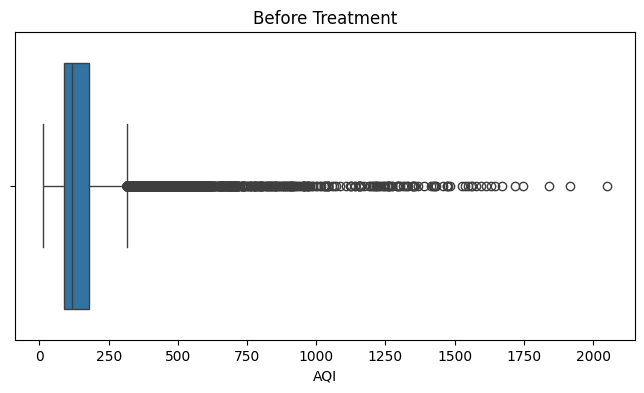

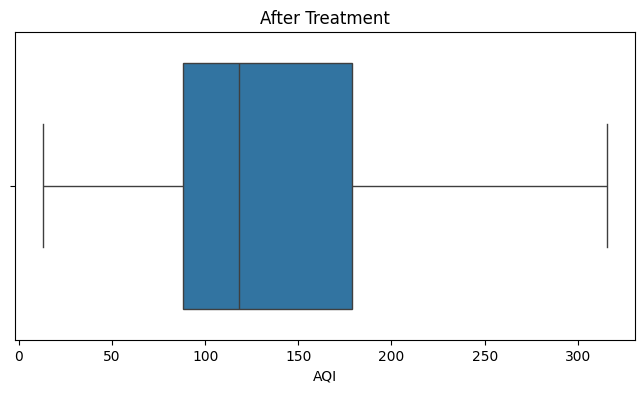

In [5]:
Q1 = aqi["AQI"].quantile(0.25)
Q3 = aqi["AQI"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = aqi[
    (aqi["AQI"] < lower) |
    (aqi["AQI"] > upper)
]

print("Outliers Found :", len(outliers))

plt.figure(figsize=(8,4))
sns.boxplot(x=aqi["AQI"])
plt.title("Before Treatment")
plt.show()


aqi["AQI"] = np.where(
    aqi["AQI"] > upper,
    upper,
    aqi["AQI"]
)

plt.figure(figsize=(8,4))
sns.boxplot(x=aqi["AQI"])
plt.title("After Treatment")
plt.show()

CONCLUSION

The AQI and crop production datasets were thoroughly inspected to assess their quality and suitability for analysis. Several issues were identified, including missing values, duplicate records, inconsistent text formatting, and extreme AQI readings. Appropriate preprocessing techniques such as median imputation, duplicate removal, text standardization, and outlier treatment were applied to improve data reliability. Visual analysis of AQI revealed that pollution levels are not uniformly distributed, with most observations concentrated in moderate ranges and a small number of extreme values significantly affecting summary statistics. After cleaning and validation, both datasets became more consistent and suitable for further exploratory analysis and machine learning applications. This preprocessing stage highlights the importance of understanding and preparing raw data before drawing conclusions or building predictive models.